In [1]:
# linked_notebooks = "https://www.kaggle.com/code/mhmdfjr/cnn-rf-malaria-cell-images-classification"

In [2]:
pip install tensorflow 

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import required modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings(action="ignore")
from matplotlib.image import imread
from sklearn.metrics import classification_report
# Import Tensorflow modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# Assign the base directory of dataset
# base_dir = "/Users/arpitojha/Downloads/cell_images"
base_dir = "C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\cell_images"
os.listdir(base_dir)

['Parasitized', 'Uninfected']

In [5]:
# Assign the directory of Parasitized and Uninfected cell images
parasitized_dir = "C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\Parasitized/"
uninfected_dir = "C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\Uninfected/"

print ('Total of Parasitized cell images: ', len(os.listdir(parasitized_dir)))
print ('Total of Uninfected cell images: ', len(os.listdir(uninfected_dir)))

Total of Parasitized cell images:  13780
Total of Uninfected cell images:  13780


In [6]:
# Print the shape image of one training data
image_shape = parasitized_dir + "/C99P60ThinF_IMG_20150918_141001_cell_133.png"
print("Shape of image: ",imread(image_shape).shape)

Shape of image:  (145, 142, 3)


In [7]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


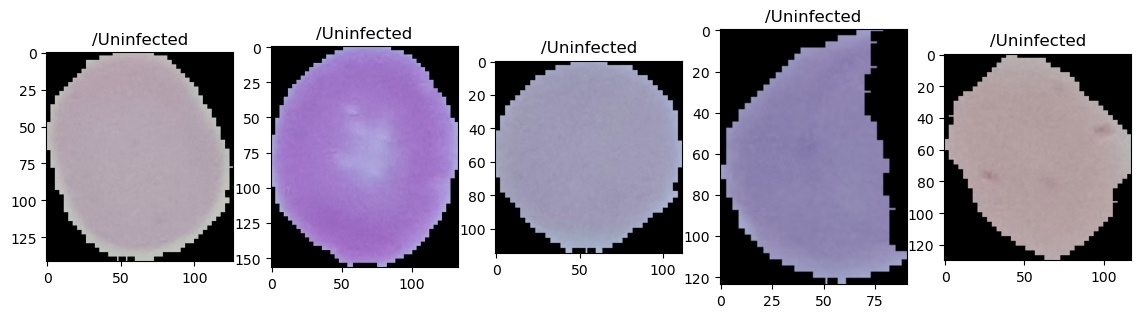

In [8]:
# Show 5 random uninfected cell images
plt.figure(figsize=(14,14))
import random, cv2
for i in range(5):
    plt.subplot(2,5,i+1)
    type1 = "/Uninfected"
    imgdir = base_dir + type1
    imgfile = np.random.choice(os.listdir(imgdir))
    img = cv2.imread(imgdir + "/" + imgfile)
    plt.imshow(img)
    plt.title(type1)
plt.show()

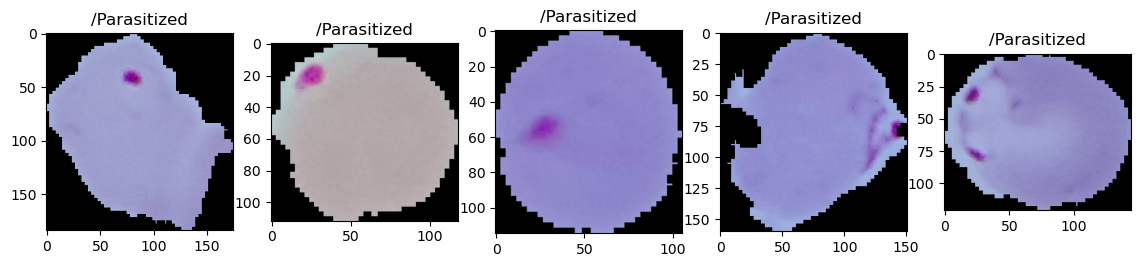

In [9]:
# Show 5 random parasitized cell images
plt.figure(figsize=(14,14))
import random, cv2
for i in range(5):
    plt.subplot(2,5,i+1)
    type2 = "/Parasitized"
    imgdir = base_dir + type2
    imgfile = np.random.choice(os.listdir(imgdir))
    img = cv2.imread(imgdir + "/" + imgfile)
    plt.imshow(img)
    plt.title(type2)
plt.show()

In [10]:
# Create image datagen for image processing
image_gen = ImageDataGenerator(rotation_range=20,
                               width_shift_range=0.1,
                               shear_range=0.1,
                               fill_mode="nearest")

In [11]:
# Split data into training set and validation set
# Create the training data generator
train_generator = tf.keras.preprocessing.image_dataset_from_directory (
    base_dir,
    validation_split=0.2,
    seed=123,
    subset="training",
    image_size=(134,131),
    batch_size=32
)
# Create the validation data generator
validation_generator = tf.keras.preprocessing.image_dataset_from_directory (
    base_dir,
    validation_split=0.2,
    seed=123,
    subset="validation",
    image_size=(134,131),
    batch_size=32
)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [13]:
#Variation2:
model = Sequential()

# Adding convolution and max-pooling layers
model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=(134,131,3),activation='relu',padding="same"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

model.add(Conv2D(filters=64, kernel_size=(3,3),input_shape=(134,131,3),activation='relu',padding="same"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

model.add(Conv2D(filters=128, kernel_size=(3,3),input_shape=(134,131,3),activation='relu',padding="same"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

model.add(Conv2D(filters=256, kernel_size=(3,3),input_shape=(134,131,3),activation='relu',padding="same"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

# Flattening image from layers
model.add(Flatten())

# Adding dense layers
model.add(Dense(128,activation='relu'))
# Adding dropout to minimize overfitting issue
model.add(Dropout(0.2))
model.add(Dense(50,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))

# Compiling the model
model.compile(loss='binary_crossentropy',optimizer='adam' ,metrics=["accuracy"])
# model.compile (loss = 'categorical_crossentropy', optimizer='RMSprop', metrics=['accuracy'])

# Show summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 134, 131, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 67, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 67, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 33, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 33, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,097,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           6,450 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,492,197 (9.51 MB)

 Trainable params: 2,492,197 (9.51 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Create early stop function for training
early_stop = EarlyStopping(monitor="val_loss",patience=5, verbose=True)

In [15]:
# Training the model
history = model.fit(train_generator,validation_data=validation_generator,epochs=10,callbacks=[early_stop],verbose=True)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.5779 - loss: 1.6418 - val_accuracy: 0.6224 - val_loss: 0.6537
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 87s 126ms/step - accuracy: 0.7300 - loss: 0.5164 - val_accuracy: 0.9525 - val_loss: 0.1652
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 86s 125ms/step - accuracy: 0.9506 - loss: 0.1625 - val_accuracy: 0.9452 - val_loss: 0.2093
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 86s 125ms/step - accuracy: 0.9570 - loss: 0.1406 - val_accuracy: 0.9559 - val_loss: 0.1357
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 97s 141ms/step - accuracy: 0.9572 - loss: 0.1316 - val_accuracy: 0.9552 - val_loss: 0.1482
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 97s 140ms/step - accuracy: 0.9618 - loss: 0.1152 - val_accuracy: 0.9526 - val_loss: 0.1467
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 90s 130ms/step - accuracy: 0.9636 - loss: 0.1093 - val_accuracy: 0.9525 - val_loss: 0.1498
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 88s 128ms/step - accuracy: 0.9662 - loss: 0

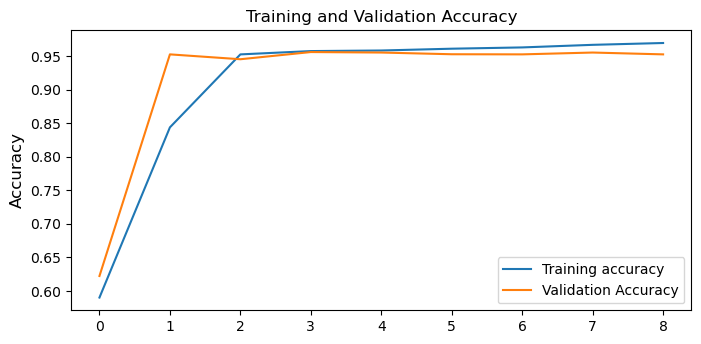

In [16]:
#Plot the training and validation accuracy and loss
acc = history.history["accuracy"]
loss = history.history["loss"]

val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(8,8))
plt.subplot(2,1,1)
plt.plot(acc,label="Training accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.ylabel("Accuracy", fontsize=12)
plt.title("Training and Validation Accuracy", fontsize=12)
plt.show()

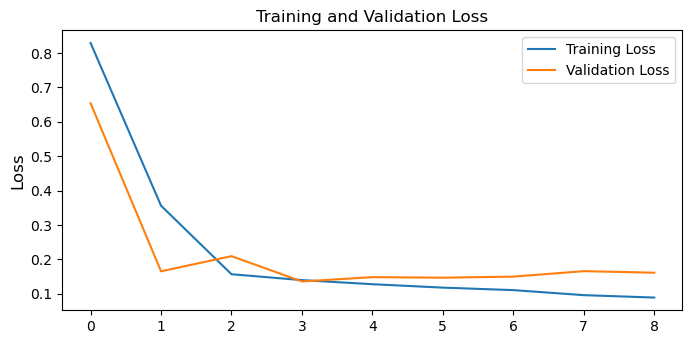

In [17]:
plt.figure(figsize=(8,8))
plt.subplot(2,1,1)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label = "Validation Loss")
plt.legend()                   
plt.ylabel("Loss", fontsize=12)
plt.title("Training and Validation Loss",fontsize=12)
plt.show()

In [18]:
model.evaluate(validation_generator, verbose=1)

173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9496 - loss: 0.1657


[0.16116246581077576, 0.9524587392807007]

In [19]:
from sklearn.metrics import accuracy_score
predictions = np.argmax(model.predict(validation_generator),axis=1)

173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step


In [20]:
predictions[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━

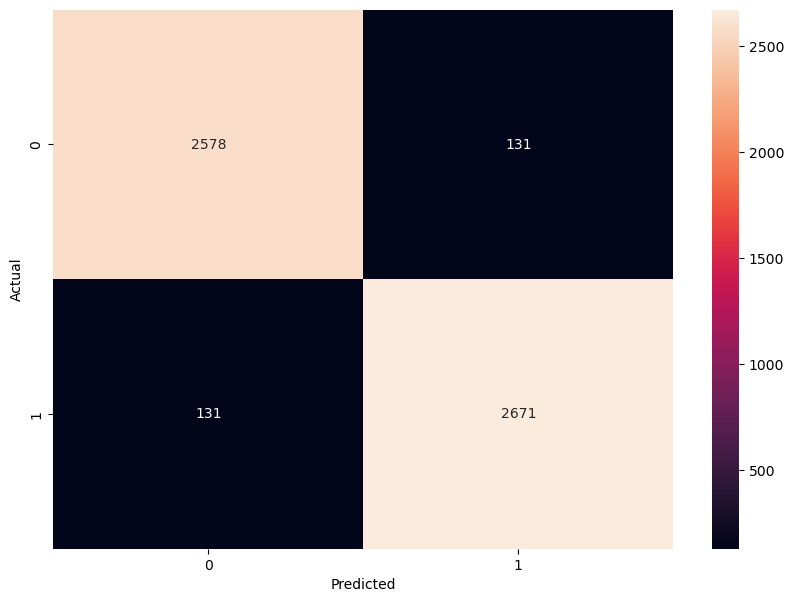

In [21]:
# Add this cell to calculate the F1 score, precision, recall, and to plot the confusion matrix
import itertools
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Get the true labels and the predicted labels
true_labels = []
predictions = []

for images, labels in validation_generator:
    true_labels.extend(labels.numpy())
    preds = model.predict(images)
    predictions.extend(preds.squeeze() > 0.5)

# Convert the true labels and predictions to the correct data types
true_labels = np.array(true_labels)
predictions = np.array(predictions).astype(int)

# Calculate classification metrics
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

# Print the precision, recall, and F1 score
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

# Plot the confusion matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
Inspired By- https://www.kaggle.com/code/anannoasif/malaria-vgg19-cnn